In [ ]:
# Save this colab notebook as name_surname
# You should upload this notebook to the moodle page of the course IE411 as classwork 5 as .ipynb notebook
# This is a 10 point classwork
# You have 60 minutes to complete this classwork

In [ ]:
# Name: Yiğit Şevki
# Surname: Kaplan
# ID: 22243810049

In [ ]:
# Load the necessary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
# Read the comedian.csv file and call the dataset as df

In [ ]:
df = pd.read_csv("comedian.csv")

In [ ]:
# Write the first 5 observations of the dataset

In [ ]:
df.head()

,Age,Experience,Rank,Nationality,Go
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES


In [ ]:
# The dataset contains information about the comedians, and your task is to decide
# whether to go or not to the comedian's show.

In [ ]:
# Write the number of observations and variables.

In [ ]:
df.shape

(13, 5)

In [ ]:
# 13 observations, 5 variable

In [ ]:
# Which variables are types of object?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          13 non-null     int64 
 1   Experience   13 non-null     int64 
 2   Rank         13 non-null     int64 
 3   Nationality  13 non-null     object
 4   Go           13 non-null     object
dtypes: int64(3), object(2)
memory usage: 652.0+ bytes


In [ ]:
# Nationality and Go

In [ ]:
# Nationality contains categorical variables. Decide how many unique categories exist and
# the number of observations for each category.

In [ ]:
df['Nationality'].value_counts()

,count
Nationality,
UK,5
USA,4
N,4


In [ ]:
#  For the Nationality transform categorical variables to numeric values. Use the following transformation
# 'UK': 0, 'USA': 1, 'N': 2

In [ ]:
df['Nationality'] = df['Nationality'].replace({'UK':0, 'USA': 1, 'N':2})

/tmp/ipython-input-1005351521.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [ ]:
# For Go transform categorical variables to numeric values. Use the following transformation
# 'YES': 1, 'NO': 0

In [ ]:
df['Go'] = df['Go'].replace({'YES': 1, 'NO': 0})

/tmp/ipython-input-1704468870.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [ ]:
# After the transformation write the first 10 observations

In [ ]:
df.head(10)

,Age,Experience,Rank,Nationality,Go
0,36,10,9,0,0
1,42,12,4,1,0
2,23,4,6,2,0
3,52,4,4,1,0
4,43,21,8,1,1
5,44,14,5,0,0
6,66,3,7,2,1
7,35,14,9,0,1
8,52,13,7,2,1
9,35,5,9,2,1


In [ ]:
#  Define X as the features of your dataset and y as the target of your model.

In [ ]:
X = df.drop(['Go'], axis = 1)
Y = df['Go']

In [ ]:
# Without dividing the data set into tests and training, fit a decision tree model.

In [ ]:
dt = DecisionTreeClassifier(random_state = 0)
dt.fit(X, Y)

DecisionTreeClassifier(random_state=0)

In [ ]:
# Plot the deicision tree and comment on the tree

[Text(0.3333333333333333, 0.875, 'x[2] <= 6.5\ngini = 0.497\nsamples = 13\nvalue = [6, 7]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[1] <= 9.5\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= 11.5\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]')]

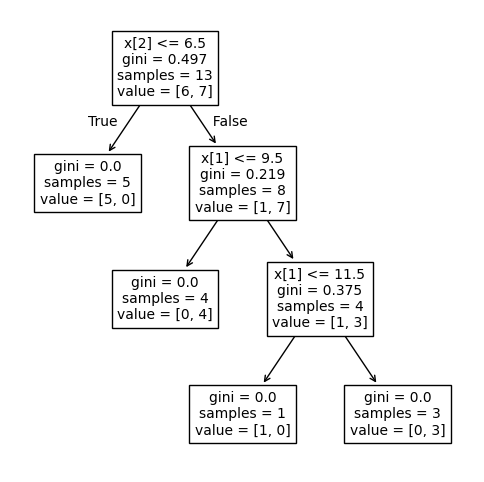

In [ ]:
plt.figure(figsize=(6,6))
plot_tree(dt, fontsize=10)

In [ ]:
# In the first seperation 5 Yes values went to 'True' branch,
# and 1 Yes, 7 No values went to 'False' branch.

# In the second seperation 4 No values went to 'True' branch,
# and 1 Yes, 3 No values went to 'False' branch.

# In the third and final seperation 1 Yes value went to 'True' branch,
# and 3 No values went to 'False' branch.

# In each seperation different metrics that effects the target value is considered.

In [ ]:
# Use dtreeviz library to plot the tree. You should first use the following command
# to install the library, then load the library.

# pip install dtreeviz


In [ ]:
pip install dtreeviz

In [ ]:
import dtreeviz

In [ ]:
viz = dtreeviz.model(dt, X, Y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names


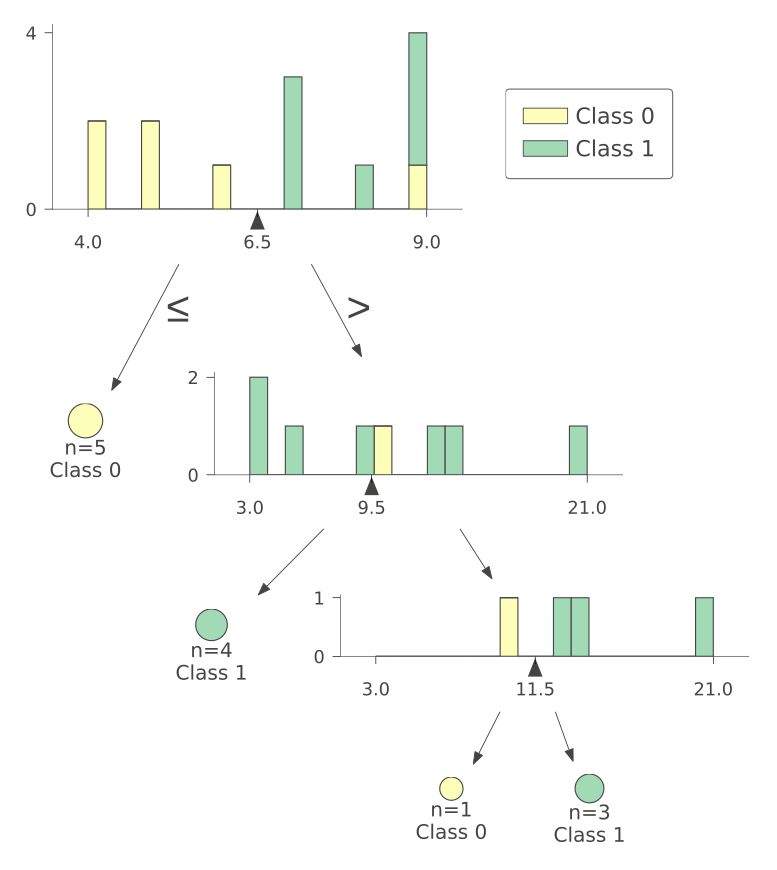

In [ ]:
viz.view(scale = 3)

In [ ]:
### Part-2 ###

In [ ]:
#Read the dataset called "heart_disease.csv" and call it "hd"

In [ ]:
hd = pd.read_csv("Heart_disease.csv")

In [ ]:
# hd['education'] = hd['education'].fillna(hd['education'].mean())
# hd['cigsPerDay'] = hd['cigsPerDay'].fillna(hd['cigsPerDay'].mean())
# hd['BPMeds'] = hd['BPMeds'].fillna(hd['BPMeds'].mean())
# hd['totChol'] = hd['totChol'].fillna(hd['totChol'].mean())
# hd['BMI'] = hd['BMI'].fillna(hd['BMI'].mean())
# hd['heartRate'] = hd['heartRate'].fillna(hd['heartRate'].mean())
# hd['glucose'] = hd['glucose'].fillna(hd['glucose'].mean())

In [ ]:
hd['education'] = hd['education'].fillna(hd['education'].mean())
hd['cigsPerDay'] = hd['cigsPerDay'].fillna(hd['cigsPerDay'].mean())
hd['BPMeds'] = hd['BPMeds'].fillna(hd['BPMeds'].mean())
hd['totChol'] = hd['totChol'].fillna(hd['totChol'].mean())
hd['BMI'] = hd['BMI'].fillna(hd['BMI'].mean())
hd['heartRate'] = hd['heartRate'].fillna(hd['heartRate'].mean())
hd['glucose'] = hd['glucose'].fillna(hd['glucose'].mean())

In [ ]:
# Write number of missing observations for each variable

In [ ]:
hd.isnull().sum()

,0
male,0
age,0
education,0
currentSmoker,0
cigsPerDay,0
BPMeds,0
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,0


In [ ]:
#  Define TenYearCHD as your y variable, the rest will be your X variables

In [ ]:
X = hd.drop(['TenYearCHD'], axis = 1)
Y = hd['TenYearCHD']

In [ ]:
#  Divide your data set into test and train sets. Test set should contain %20 of the data set. Use random state as 123

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 123)

In [ ]:
# Fit a support vector machine algorithm with linear kernel anc C=1

In [ ]:
svc = svm.SVC()
svc.fit(x_train, y_train)

SVC()

In [ ]:
# Calculate the accuracy of the model on train set

In [ ]:
y_pred = svc.predict(x_train)

In [ ]:
accuracy_score(y_train, y_pred)

0.8519174041297936

In [ ]:
# Calculate the accuracy of the model on test set

In [ ]:
y_pred_test = svc.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_test)

0.8360849056603774

In [ ]:
# Fit a support vector machine algorithm with polynomial kernel anc C=0.1

In [ ]:
svc_c01_poly = svm.SVC(kernel = 'poly', C = 0.1)
svc_c01_poly.fit(x_train, y_train)

SVC(C=0.1, kernel='poly')

In [ ]:
# Calculate the accuracy of the model on train set

In [ ]:
y_pred_c01_poly = svc_c01_poly.predict(x_train)

In [ ]:
accuracy_score(y_train, y_pred_c01_poly)

0.8516224188790561

In [ ]:
# Calculate the accuracy of the model on test set

In [ ]:
y_pred_c01_poly_test = svc_c01_poly.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred_c01_poly_test)

0.8349056603773585

In [ ]:
# Now fit another SVM, in which you are going to decide hyperparameters and calculate the accuracy of the test set.

In [ ]:
svc_c10_lin = svm.SVC(kernel = 'linear', C = 10)

In [ ]:
svc_c10_lin.fit(x_train, y_train)

SVC(C=10, kernel='linear')

In [ ]:
y_pred_c10_lin = svc_c10_lin.predict(x_train)
accuracy_score(y_train, y_pred_c10_lin)

0.856637168141593

In [ ]:
y_pred_c10_lin_test = svc_c10_lin.predict(x_test)
accuracy_score(y_test, y_pred_c10_lin_test)

0.8384433962264151

In [ ]:
# Which SVM has the highest accuracy on the test set?

In [ ]:
# The last SVM we did which is (krenel = 'linear', C=10) has the highest
# accuracy_score on both train and test sets.